# Does a bear flag actually "continue the drop"? 🏴
### A famous chart pattern — a sharp fall, a little pause, then *the second leg down* — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_continuation%3F: Busted](https://img.shields.io/badge/Forecasts_continuation%3F-Busted-8b949e?style=flat-square)

Open any chart-pattern course and you'll meet the **bear flag**: a fast, near-vertical drop (the *pole*), then a small, calm, slightly *up-sloping* drift (the *flag*), and then — the lore says — a **breakdown** that launches the *second leg down*, often the same size as the pole. So when price breaks below the little flag, you **short**: the drop is "supposed" to continue.

It *looks* uncanny on a hand-picked chart. But a shape you label **after** the move — choosing which drop is a 'pole' and which drift is a 'flag' — is the textbook setup for fooling yourself. So we did the only fair thing: encode the bear flag **mechanically** (no eyeballing), fire the "short the breakdown" rule across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bear_flag import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real bear-flag cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 156, 'fp_spy': '4cb5244f3990', 'h5': (5, 156, -57.5, 46, -1.92, -10.3, -47.2, -59.5, -1.24, 0.218), 'h10': (10, 155, -57.3, 41, -1.55, -53.6, -3.7, -59.3, -0.07, 0.944), 'h20': (20, 155, -98.2, 47, -1.65, -33.1, -65.1, -100.2, -1.04, 0.299), 'h60': (60, 153, -303.2, 29, -3.39, -118.9, -184.2, -305.2, -1.9, 0.059), 'per': [('SPY', 27, 73.9, 0.56, -39.3, 113.2), ('QQQ', 31, -177.3, -1.63, -88.2, -89.1), ('IWM', 46, -70.3, -0.8, -2.7, -67.6), ('DIA', 20, -141.2, -0.68, -33.7, -107.4), ('GLD', 32, -182.4, -1.35, -1.5, -180.9)], 'placebo': (73.9, 0.323, 500), 'syn': [(0.0, 73, 36.5, 49, 0.67), (0.8, 100, 511.5, 87, 10.74)]}


real bear-flag cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I short when price breaks down out of the flag, does the drop continue? | **No.** The short **loses money at every horizon** — after the breakdown, price tends to *bounce*, not fall further. |
| Is the breakdown worse than shorting on random days? | **Yes.** A short on a *random* day does **better** (less badly) than the famous breakdown short. The flag adds nothing. |
| Does the flag's *shape* do the work? | **No.** Replace the up-sloping flag with a coin-flip and the result barely changes. The geometry isn't carrying any information. |
| So is it a tradable edge? | **No.** It's a way to **short into the market's upward drift** — a slow bleed dressed up as a pattern. |

> The bear flag is a great way to *narrate* a drop after the fact. As a *forecast* — "the breakdown continues down" — it's a **mirage**: the breakdown is, if anything, a short-term *bottom*, and shorting it just pays the drift the wrong way.

## 1 · The claim

> *"A sharp drop is the **pole**. The small, up-sloping pause that follows is the **flag**. When price breaks **below** the flag, the second leg down begins — short it, and target a **measured move** the size of the pole. Flags are *continuation* patterns: the trend resumes."*

This is the **flag/pennant** rule from the founding charting texts (Edwards & Magee, 1948) and the modern pattern catalogues (Bulkowski's *Encyclopedia of Chart Patterns*; Murphy's *Technical Analysis of the Financial Markets*). It's one of the most recognisable setups in technical analysis — so: does the flag actually *forecast* the continuation?

## 2 · So what?

If the flag genuinely *forecast* the second leg down, it would be remarkable: a small consolidation shape would predict the next move's *direction*, a clean crack in market efficiency you could trade with a ruler. That's the dream the pattern sells.

But there are two traps. First, a bear flag is **labelled by hand, after the swings have happened** — you pick the drop and the drift that make the flag *look* right. Second, stock indices drift **up** over time, so *any* short is fighting a headwind — which makes a losing short look 'almost right'. To separate the **pattern** from the **tide**, we (a) detect the flag by a fixed mechanical rule with no hindsight, and (b) compare the breakdown short to shorting on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the pole mechanically.** A sharp drop: the close falls at least **6%** over a 10-bar window — measurable, no eyeballing.
2. **Find the flag by rule.** The next **7 bars** must drift gently *up* (a positive slope, against the pole) without retracing more than 60% of the drop — a pause, not a reversal.
3. **Trade the lore.** When the close breaks **below the flag's lower line**, short at the next close; measure the return over the next **5 / 10 / 20 / 60 days** (a continued drop = a profit).
4. **The honest baseline.** Do the exact same short on **random days**. If the flag matters, the breakdown short must beat random. *If it doesn't, the pattern is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical bear flag even look like? Here's a stretch of SPY with the detected flag windows and the breakdown bars the rule would short.

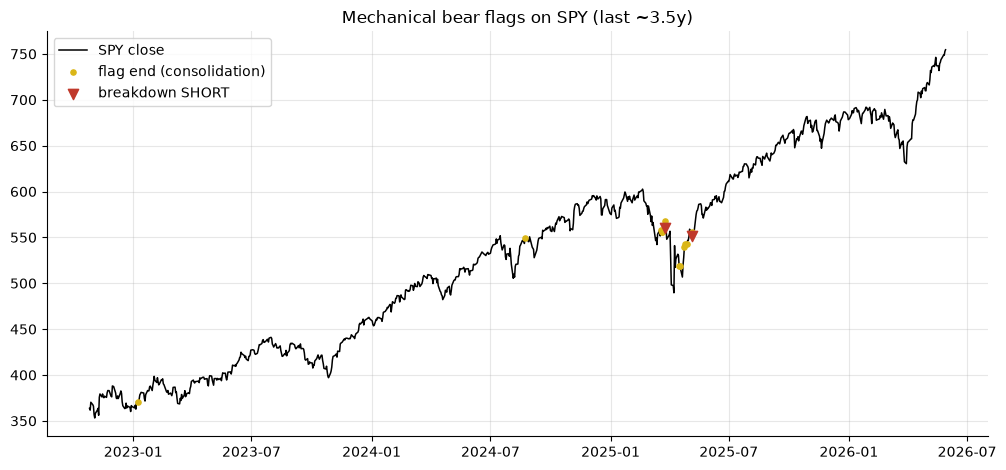

breakdown shorts in window: 2


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-900:]
    flags = st.detect_flags(cl)
    ent = st.breakdown_entries(cl)
    ent = ent[ent >= seg.index[0]]
    fent = flags.reindex(seg.index).fillna(False)
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.1, label='SPY close')
    ax.scatter(seg.index[fent.to_numpy()], seg[fent.to_numpy()], c=AMBER, s=14, zorder=4, label='flag end (consolidation)')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=55, marker='v', zorder=5, label='breakdown SHORT')
    ax.set_title('Mechanical bear flags on SPY (last ~3.5y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('breakdown shorts in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

Now the test. **Race the breakdown short against shorting on random days** at four horizons. A *positive* bar means the short made money (the drop continued). Red = short the breakdown; grey = short on random days.

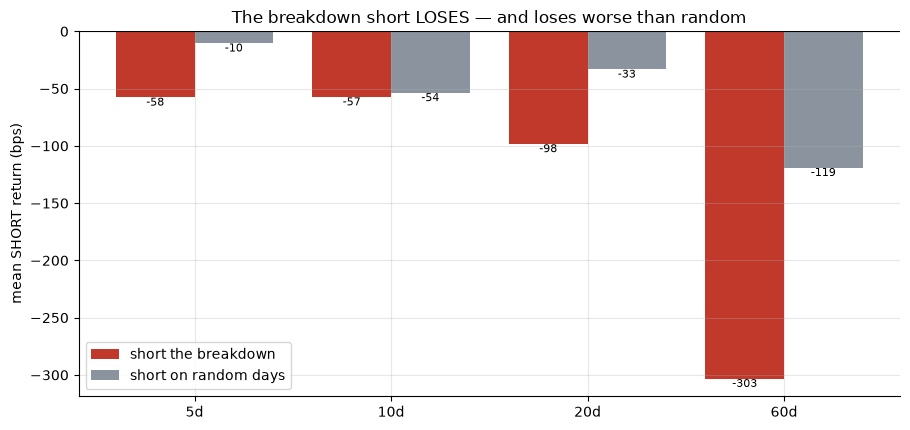

breakdown: [-58, -57, -98, -303]
random: [-10, -54, -33, -119]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.breakdown_entries(c)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color=RED, label='short the breakdown')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top' if a<0 else 'bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top' if bb<0 else 'bottom',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('The breakdown short LOSES — and loses worse than random'); ax.legend()
plt.tight_layout(); plt.show()
print('breakdown:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The breakdown short **loses money at every horizon** (**-98 bps** over 20 days, **-303 bps** over 60) — after the 'continuation' breakdown, price tends to *go up*, not down. And it's *worse* than shorting on random days at every horizon. The pattern doesn't continue the drop; if anything the breakdown is a short-term **bottom**.

**One more sanity check.** What if we scramble the flag's *shape* — keep the sharp-drop pole filter, but decide whether each bar is a 'flag' by coin flip instead of the up-sloping test? If price really respects *the flag*, the nonsense flag should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_flag_placebo(c, 20, n_draws=200, seed=463)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real flag breakdown short (SPY, 20d): {obs:+.1f} bps')
print(f'... and {pval*100:.0f}% of *coin-flip-flag* breakdowns do at least as well (p={pval:.2f}).')
print('=> the flag geometry is not doing the work.')

real flag breakdown short (SPY, 20d): +73.9 bps
... and 32% of *coin-flip-flag* breakdowns do at least as well (p=0.32).
=> the flag geometry is not doing the work.


About a third of the **coin-flip** flags match or beat the real one (*p* = 0.32). If price genuinely respected *the flag's shape*, a scramble would collapse the result. It doesn't — because the result was never about the flag.

## 5 · The verdict

- **Signal — None.** The breakdown short does **not** beat shorting on random days (it's *worse* at every horizon; the breakdown-vs-random difference never clears *t* = 2). The short simply loses to the market's upward drift.
- **Tradability — Mirage.** There's no continuation to capture — only a slow bleed from shorting a rising index, made worse by costs.
- **"Does the flag forecast continuation"? — Busted.** Replace the flag shape with a coin flip and the result barely moves. The flag doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade — and worse than nothing. The breakdown short is a way to stand in front of the market's long-run climb and get run over: it loses on average at every horizon and the loss *deepens* with time (−303 bps at 60 days). Costs (commissions + spread on every breakdown) only add to the bleed. As a forecasting pattern, the bear flag doesn't pay; as a drawing tool, it was never meant to be a strategy on a drifting index.

## 7 · Going further 🚪

- **The measured move.** The lore's headline target is a drop the size of the pole. That's a *conditional* claim you can test directly — and on this tape the conditional drop simply doesn't show up.
- **Different thresholds.** Try a steeper pole, a tighter flag, a stricter slope — the result is robust: drift in, no continuation out.
- **A real positive control.** The quants notebook plants a *genuine* post-breakdown continuation into a synthetic tape and shows the harness banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think the flag forecasts? Show the breakdown short beating random shorts at **t ≥ 2** on a real tape — then we'll talk.*